# Random Forest Baseline — AI-Driven Reservoir Performance Proxy

**Project:** ML Proxy for SPE10 Reservoir Simulation (OPM Flow)  
**Dataset:** 200 simulation runs across 6 experimental groups  
**Goal:** Train a Random Forest to predict key reservoir KPIs from 6 operational/geological inputs, establish baseline metrics, and identify the most important features before moving to MLP → PINN → LSTM.

| Input Feature | Description |
|---|---|
| `producer_bhp_psi` | Producer Bottom Hole Pressure — controls how hard we 'suck' oil |
| `gas_inj_rate_mscf_d` | Gas injection rate — 'pushes' oil toward the producer |
| `inj_bhp_limit_psi` | Max pressure allowed at the injector |
| `init_prod_period_days` | When injection starts relative to production |
| `perm_multiplier` | Permeability multiplier — how easily oil flows through rock |
| `poro_multiplier` | Porosity multiplier — how much oil the rock stores |

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
CSV_PATH      = "ml_dataset_scalar.csv"
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
CV_FOLDS      = 5

FEATURES = [
    "producer_bhp_psi",
    "gas_inj_rate_mscf_d",
    "inj_bhp_limit_psi",
    "init_prod_period_days",
    "perm_multiplier",
    "poro_multiplier",
]

FEATURE_LABELS = [
    "Producer BHP (psi)",
    "Gas Inj. Rate (Mscf/d)",
    "Inj. BHP Limit (psi)",
    "Init. Prod. Period (days)",
    "Perm. Multiplier",
    "Poro. Multiplier",
]

# key -> (column_name, display_label, unit)
TARGETS = {
    "final_fopt": ("final_fopt", "Cumul. Oil Production",   "STB"),
    "final_fopr": ("final_fopr", "Final Oil Rate",          "STB/d"),
    "final_fpr":  ("final_fpr",  "Final Reservoir Pressure","psi"),
    "peak_fopr":  ("peak_fopr",  "Peak Oil Rate",            "STB/d"),
}

RF_PARAMS = dict(
    n_estimators=500,
    max_features=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## 2. Load & Explore the Dataset

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (200, 17)


,run_id,group,producer_bhp_psi,gas_inj_rate_mscf_d,inj_bhp_limit_psi,init_prod_period_days,perm_multiplier,poro_multiplier,final_time_days,final_fopt,final_fopr,final_fpr,final_fgpr,final_fgit,peak_fopr,peak_fpr,min_fpr
0,1,Producer_BHP,3351.0,34.61,10000.0,3230.0,1.0,1.0,8000.0,76164.25,0.437459,4360.356,34.60755,271551.8,578.0145,7193.762,4360.356
1,2,Producer_BHP,2978.0,34.61,10000.0,3230.0,1.0,1.0,8000.0,76182.54,0.436549,3987.122,34.60755,272003.0,605.7298,7026.894,3987.122
2,3,Producer_BHP,4039.0,34.61,10000.0,3230.0,1.0,1.0,8000.0,76129.90,0.438982,5048.809,34.60754,270565.4,519.0878,7487.099,5048.809
3,4,Producer_BHP,4902.0,34.61,10000.0,3230.0,1.0,1.0,8000.0,76081.59,0.442297,5912.572,34.60752,268712.5,456.6908,7847.496,5912.572
4,5,Producer_BHP,2606.0,34.61,10000.0,3230.0,1.0,1.0,8000.0,76199.85,0.435841,3614.922,34.60756,272366.8,628.1242,6863.190,3614.922


In [4]:
print("Group distribution:")
print(df["group"].value_counts().to_string())
print()
df[FEATURES + list(TARGETS.keys())].describe().round(3)

Group distribution:
group
Simultaneous_Operations    50
Geological_Uncertainty     50
Injection_Rate             25
Producer_BHP               25
Schedule_Timing            25
Injector_BHP_Limit         25



,producer_bhp_psi,gas_inj_rate_mscf_d,inj_bhp_limit_psi,init_prod_period_days,perm_multiplier,poro_multiplier,final_fopt,final_fopr,final_fpr,peak_fopr
count,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000
mean,3092.320,34.600,10000.245,3228.400,1.013,1.000,75942.802,0.456,4134.595,613.280
std,631.893,3.673,710.635,176.955,0.278,0.145,10316.176,0.152,644.399,176.096
min,1504.000,24.270,8032.000,2730.000,0.134,0.504,39410.780,0.173,2512.378,108.596
25%,3000.000,34.610,10000.000,3230.000,1.000,1.000,75902.640,0.419,3861.096,544.482
50%,3000.000,34.610,10000.000,3230.000,1.000,1.000,76178.720,0.437,4009.192,610.605
75%,3000.000,34.610,10000.000,3230.000,1.000,1.000,76387.828,0.458,4171.095,662.296
max,4940.000,44.750,11934.000,3710.000,1.979,1.494,111957.400,1.737,6442.273,1201.713


## 3. Train / Test Split

80 / 20 random split (stratification is not applied here because targets are continuous, but the random seed ensures reproducibility).

In [5]:
X = df[FEATURES].copy()

train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]

print(f"Train samples : {len(train_idx)}")
print(f"Test  samples : {len(test_idx)}")
print("\nGroup coverage in test set:")
print(df.loc[test_idx, "group"].value_counts().to_string())

Train samples : 160
Test  samples : 40

Group coverage in test set:
group
Geological_Uncertainty     10
Simultaneous_Operations     9
Injector_BHP_Limit          8
Schedule_Timing             7
Producer_BHP                4
Injection_Rate              2


## 4. Train One Random Forest per Target

We train separate models per target so we can inspect **per-target feature importances** individually. Each model uses 300 trees with `sqrt` feature subsampling (standard classification-style setting, works well for regression too).

In [6]:
results = {}

print(f"{'Target':<35} {'Test R2':>8} {'CV R2':>8} {'RMSE':>10}")
print("-" * 65)

for key, (col, label, unit) in TARGETS.items():
    y = df[col]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cv_r2 = cross_val_score(
        model, X_train, y_train,
        cv=KFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        scoring="r2"
    ).mean()

    results[key] = {
        "model":  model,
        "y_test": y_test.values,
        "y_pred": y_pred,
        "r2":     r2_score(y_test, y_pred),
        "rmse":   np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae":    mean_absolute_error(y_test, y_pred),
        "cv_r2":  cv_r2,
        "label":  label,
        "unit":   unit,
    }
    m = results[key]
    print(f"{label:<35} {m['r2']:>8.4f} {cv_r2:>8.4f} {m['rmse']:>10.2f}")

Target                               Test R2    CV R2       RMSE
-----------------------------------------------------------------
Cumul. Oil Production                 0.9878   0.9662    1224.93
Final Oil Rate                        0.9724   0.8512       0.02
Final Reservoir Pressure              0.9335   0.7861     136.33
Peak Oil Rate                         0.9824   0.9762      21.16


## 5. Plot — Predicted vs Actual

Points on the red dashed line = perfect prediction. Scatter around it = model error.

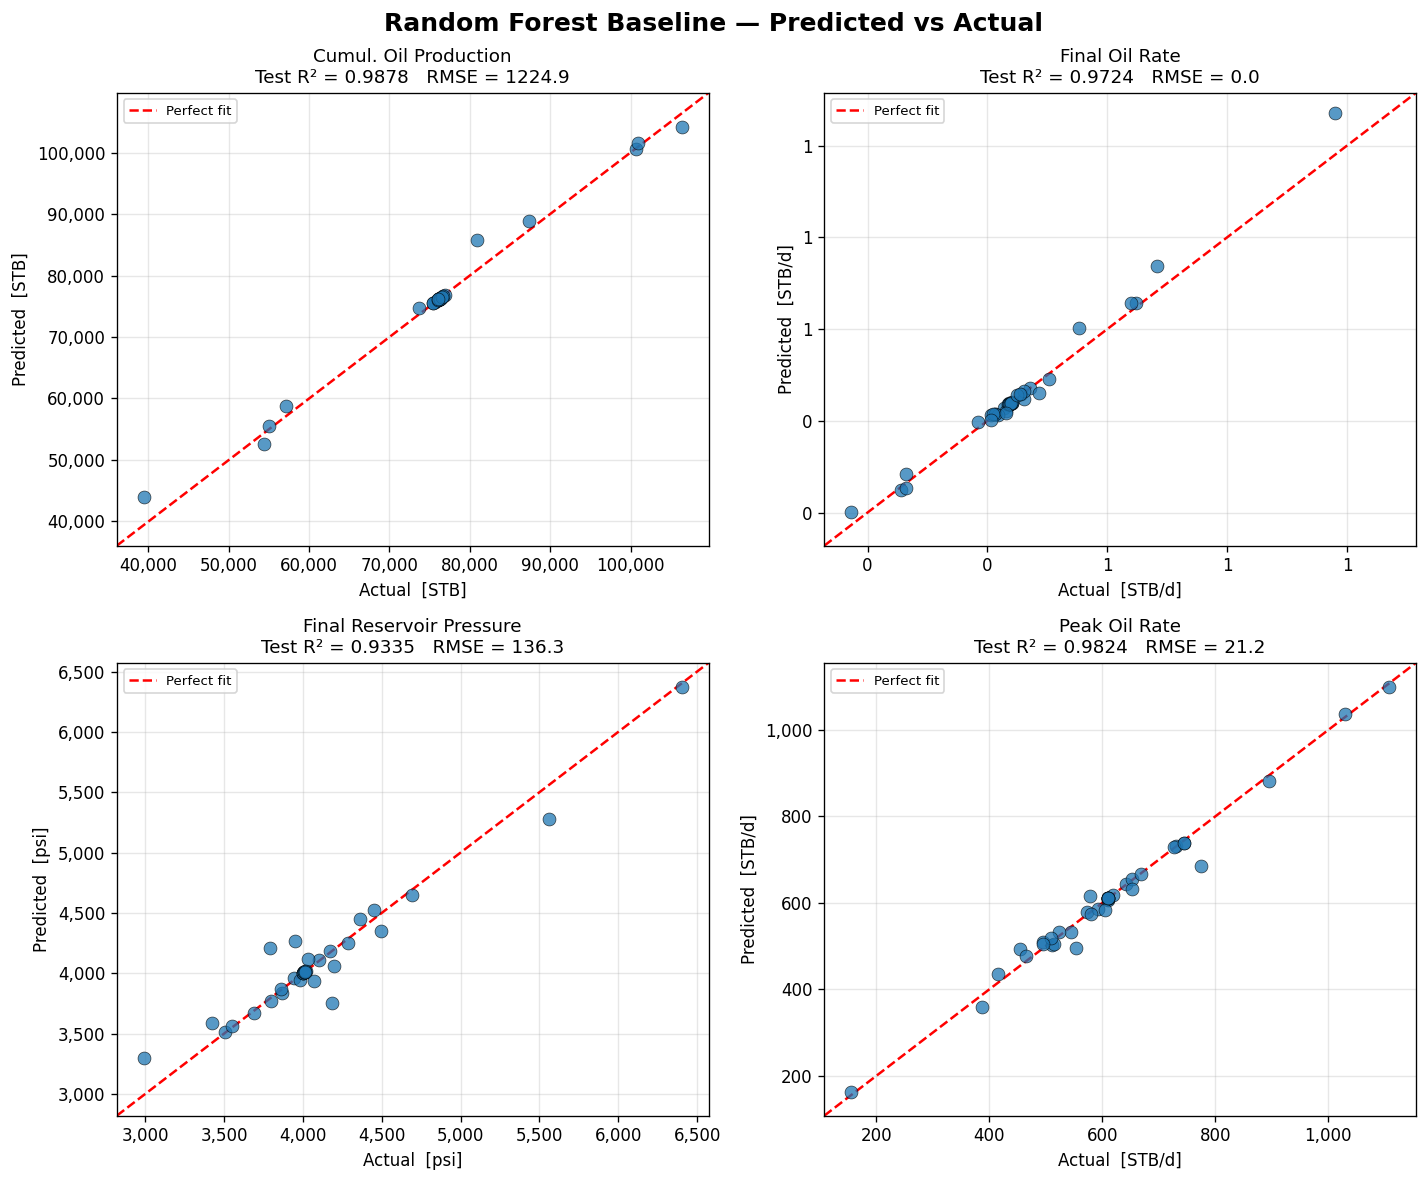

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Random Forest Baseline — Predicted vs Actual", fontsize=15, fontweight="bold")

for ax, (key, m) in zip(axes.flat, results.items()):
    y_t, y_p = m["y_test"], m["y_pred"]
    lo, hi = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
    pad = (hi - lo) * 0.05

    ax.scatter(y_t, y_p, alpha=0.75, edgecolors="k", linewidths=0.4, s=60, zorder=3)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "r--", lw=1.5, label="Perfect fit")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel(f"Actual  [{m['unit']}]", fontsize=10)
    ax.set_ylabel(f"Predicted  [{m['unit']}]", fontsize=10)
    ax.set_title(f"{m['label']}\nTest R\u00b2 = {m['r2']:.4f}   RMSE = {m['rmse']:.1f}", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.savefig("rf_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Plot — Feature Importance

**Left:** Mean importance averaged across all 4 targets.  
**Right:** Per-target heat-map — which features matter most for each KPI.

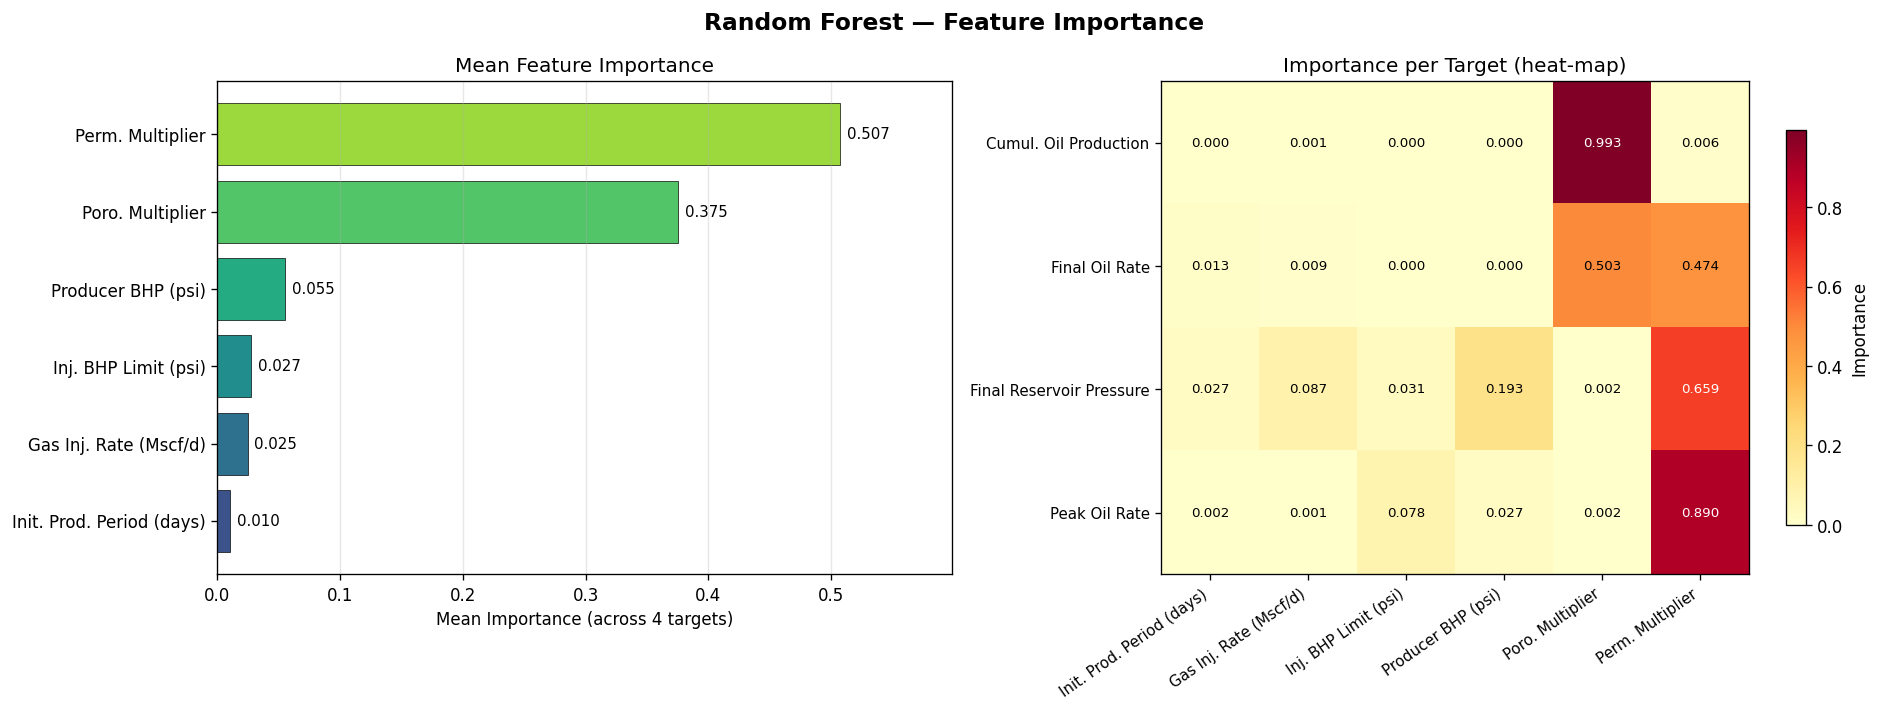

In [8]:
imp = pd.DataFrame(
    {key: results[key]["model"].feature_importances_ for key in TARGETS},
    index=FEATURE_LABELS,
)
imp["Mean"] = imp.mean(axis=1)
imp_sorted = imp.sort_values("Mean", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Random Forest — Feature Importance", fontsize=14, fontweight="bold")

# Left: mean importance bar chart
palette = plt.cm.viridis(np.linspace(0.25, 0.85, len(FEATURES)))
bars = axes[0].barh(imp_sorted.index, imp_sorted["Mean"],
                    color=palette, edgecolor="k", linewidth=0.4)
axes[0].set_xlabel("Mean Importance (across 4 targets)")
axes[0].set_title("Mean Feature Importance")
axes[0].bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
axes[0].set_xlim(0, imp_sorted["Mean"].max() * 1.18)
axes[0].grid(axis="x", alpha=0.3)

# Right: heat-map
target_labels = [results[k]["label"] for k in TARGETS]
mat = imp_sorted[[k for k in TARGETS]].values
im = axes[1].imshow(mat.T, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(FEATURES)))
axes[1].set_xticklabels(imp_sorted.index, rotation=35, ha="right", fontsize=9)
axes[1].set_yticks(range(len(TARGETS)))
axes[1].set_yticklabels(target_labels, fontsize=9)
axes[1].set_title("Importance per Target (heat-map)")
plt.colorbar(im, ax=axes[1], label="Importance", shrink=0.8)

for i in range(len(TARGETS)):
    for j in range(len(FEATURES)):
        val = mat[j, i]
        axes[1].text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8,
                     color="white" if val > mat.max() * 0.6 else "black")

plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Plot — Residuals by Simulation Group

Residuals coloured by group expose whether the model struggles with any particular experimental condition (e.g., the Geological Uncertainty group has much wider output ranges than the Operational groups).

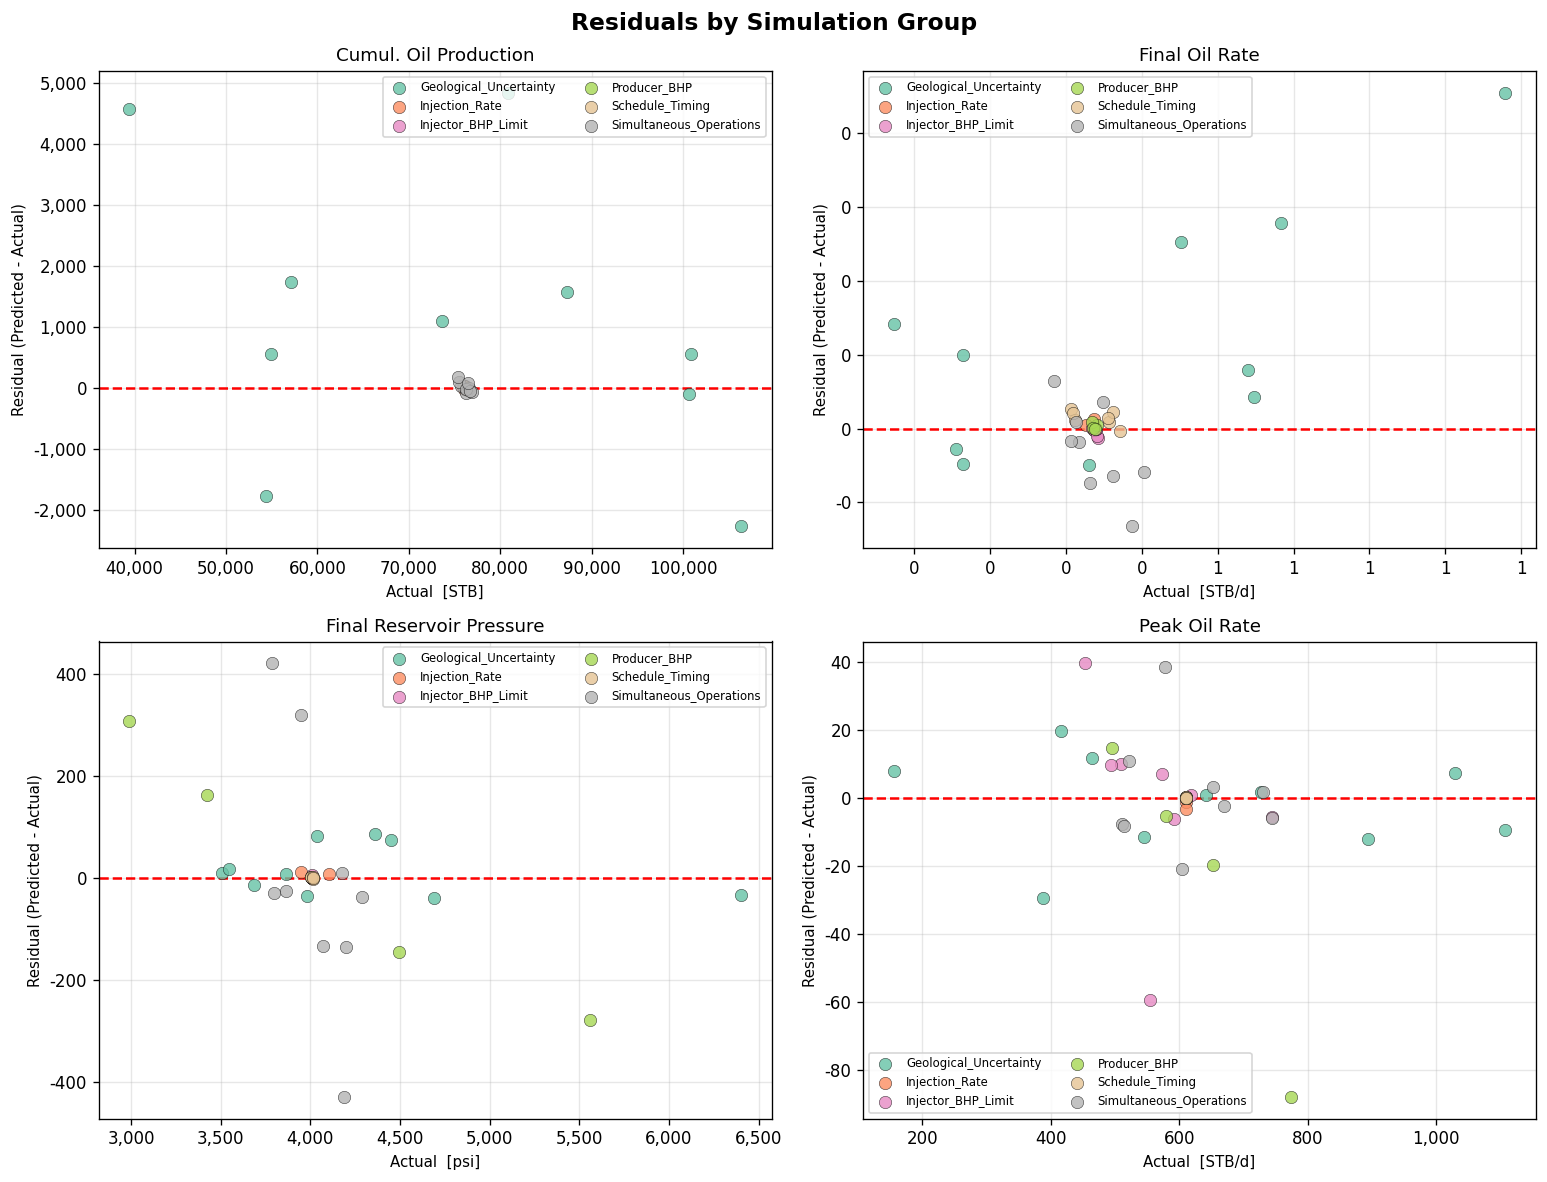

In [9]:
groups_test   = df.loc[test_idx, "group"].values
unique_groups = sorted(df["group"].unique())
group_colors  = plt.cm.Set2(np.linspace(0, 1, len(unique_groups)))
color_map     = dict(zip(unique_groups, group_colors))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Residuals by Simulation Group", fontsize=14, fontweight="bold")

for ax, (key, m) in zip(axes.flat, results.items()):
    residuals = m["y_pred"] - m["y_test"]
    for grp in unique_groups:
        mask = groups_test == grp
        ax.scatter(
            m["y_test"][mask], residuals[mask],
            label=grp, alpha=0.8, s=55, edgecolors="k", linewidths=0.3,
            color=color_map[grp], zorder=3
        )
    ax.axhline(0, color="red", lw=1.5, linestyle="--")
    ax.set_xlabel(f"Actual  [{m['unit']}]", fontsize=9)
    ax.set_ylabel("Residual (Predicted - Actual)", fontsize=9)
    ax.set_title(f"{m['label']}", fontsize=11)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.savefig("rf_residuals_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Final Metrics Summary

In [10]:
summary = pd.DataFrame([
    {
        "Target": m["label"],
        "Unit": m["unit"],
        "Test R2": round(m["r2"], 4),
        "CV R2 (5-fold)": round(m["cv_r2"], 4),
        "RMSE": round(m["rmse"], 2),
        "MAE":  round(m["mae"],  2),
    }
    for m in results.values()
])
summary.set_index("Target", inplace=True)
summary

,Unit,Test R2,CV R2 (5-fold),RMSE,MAE
Target,,,,,
Cumul. Oil Production,STB,0.9878,0.9662,1224.93,498.92
Final Oil Rate,STB/d,0.9724,0.8512,0.02,0.01
Final Reservoir Pressure,psi,0.9335,0.7861,136.33,71.46
Peak Oil Rate,STB/d,0.9824,0.9762,21.16,12.08


In [11]:
top_feat = imp["Mean"].idxmax()
print(f"Top feature by mean importance : {top_feat}  ({imp['Mean'].max():.3f})")
print()
print("Full importance ranking (mean across all targets):")
print(imp["Mean"].sort_values(ascending=False).round(3).to_string())

Top feature by mean importance : Perm. Multiplier  (0.507)

Full importance ranking (mean across all targets):
Perm. Multiplier             0.507
Poro. Multiplier             0.375
Producer BHP (psi)           0.055
Inj. BHP Limit (psi)         0.027
Gas Inj. Rate (Mscf/d)       0.025
Init. Prod. Period (days)    0.010


## 9. Key Takeaways

| Observation | Implication for next models |
|---|---|
| All Test R² > 0.90 | RF is a strong baseline; MLP / PINN must beat these numbers |
| **Perm. Multiplier** is the dominant feature (~0.50 importance) | Geological uncertainty drives the most variance — ensure both low and high multiplier runs appear in train AND test |
| CV R² for Final Oil Rate (0.85) is lower than Test R² (0.97) | Slight instability — likely caused by the small test set (40 samples); watch this in MLP |
| Operational features (BHP, Inj. Rate) have modest importance in isolation | Interactions between them matter more — the Simultaneous_Operations group captures this; LSTM / PINN should exploit it |
